### Setup GoogleColab environment

Install hylite and download tutorial data

In [1]:
# download demo dataset (https://drive.google.com/file/d/1X8xR1LxB7VR_JuvdmDwqJXeSILr9LP-n/view?usp=drive_link)
!gdown 1X8xR1LxB7VR_JuvdmDwqJXeSILr9LP-n
!unzip demo_data.zip

from IPython.display import clear_output
clear_output() # clear output (it isn't easy being clean!)

In [2]:
# install hylite
! pip install git+https://github.com/hifexplo/hylite.git
clear_output() # clear output (it isn't easy being clean!)

In [3]:
import hylite
from hylite import io
from hylite.hylibrary import from_indices
import matplotlib.pyplot as plt

import numpy as np

In [4]:
%matplotlib inline

### 1. Principal component analysis

Hyperspectral data is by nature very high-dimensional. Furthermore, adjacent spectral bands tend to correlate, meaning a large number of these dimensions are redundant. For this reason, it is very common to apply statistical dimensionality reduction techniques to reduce a dataset to a small (1-20) set of uncorrelated feaures.

On good-quality data (e.g. from laboratory scanning instruments) then principal component analysis (PCA) is a popular approach. In the following, we use PCA to reduce a hyperspectral dataset to 3 uncorrelated components and visualise the results as a false colour image.

In [5]:
# load a dataset to play with
image = io.load( 'test_data/image.hdr' )
image.set_as_nan(0) # remove background
print("Dataset contains %d spectral dimensions" % image.band_count())

Dataset contains 55 spectral dimensions


In [6]:
from hylite.filter import PCA
PCA?

Preserved variance per band: 99.241, 99.664, 99.898


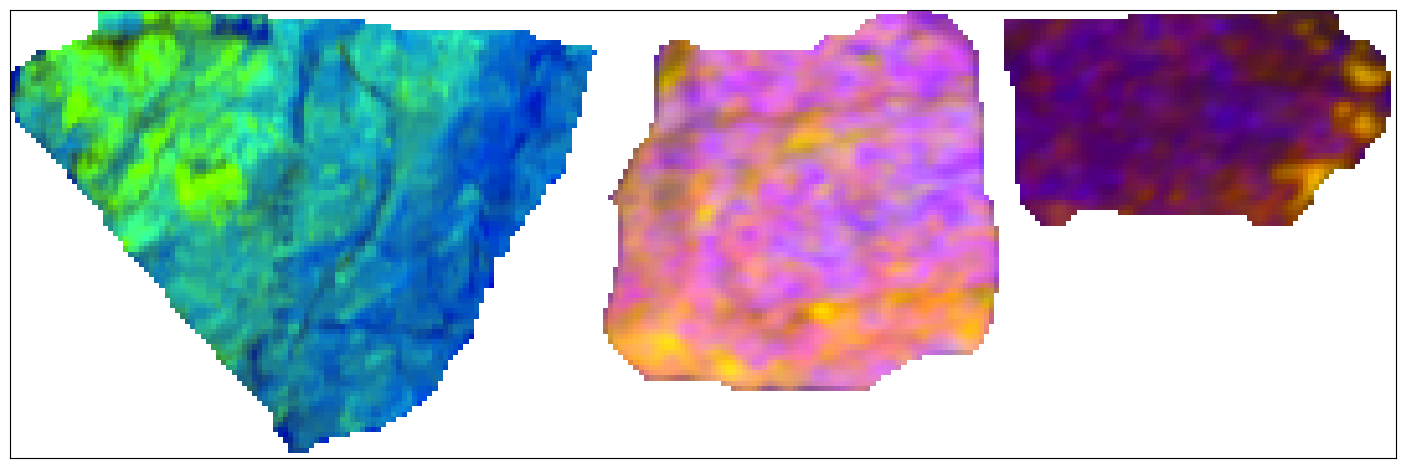

In [7]:
pca, loadings, means = PCA( image, bands=3 )
pca.quick_plot((0,1,2),vmin=2, vmax=98, tscale=True)

# amount of (cumulative) "preserved" variance per band are stored as the wavelengths :-)
print("Preserved variance per band: %.3f, %.3f, %.3f"%tuple(pca.get_wavelengths()*100))

This result does an excellent job at conveying spatial variations in the dataset, and preserves most of the variation, but is very difficult to interpret in terms of mineralogy. Hence this approach is usually used either for exploratory data analysis or as a precursor to e.g. a supervised machine learning method that translates these features into more meaningful information.

However, in some contexts it can be useful to interpret the loading vectors; as values that are significantly different to zero can imply a link between specific spectral ranges and each of the features.

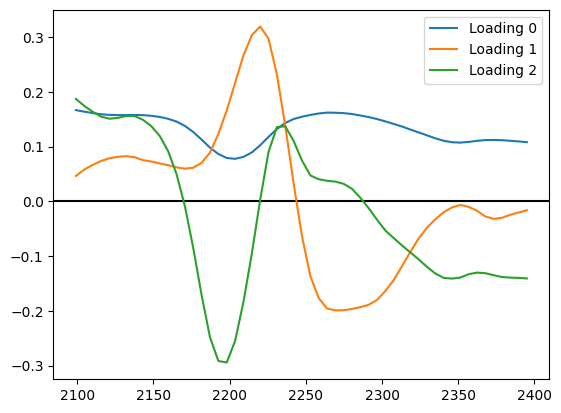

In [8]:
plt.axhline(0,color='k')
for i, b in enumerate(range(pca.band_count())):
    plt.plot(image.get_wavelengths(), loadings[b,:], label="Loading %d"%i)
plt.legend()
plt.show()

### 2. Minimum noise filter

The PCA transform preserves as much of the variance in the original dataset as possible in the low-dimensional space. While conceptually this is an excellent idea, in practice this has the undesired side-effect of amplifying any really noisy bands; noise is variance too!

Hence, for datasets that contain noise that is not evenly distributed across the bands (e.g. due to atmospheric effects in outdoor scenes), it is common to use a minimum noise filter (MNF). This is conceptually similar to a PCA, but it downweights the importance of noisy bands. Technically this requires an estimate of the amount of noise per-band; but *hylite* (crudely) estimates this by comparing adjacent pixels (and assuming that the signal in the image is spatially smooth).

First, lets calculate an MNF for the above image (for comparison), and then apply it too an outdoor scene (the hypercloud).

In [9]:
from hylite.filter import MNF
MNF?

(<Figure size 1800x582.156 with 1 Axes>, <Axes: >)

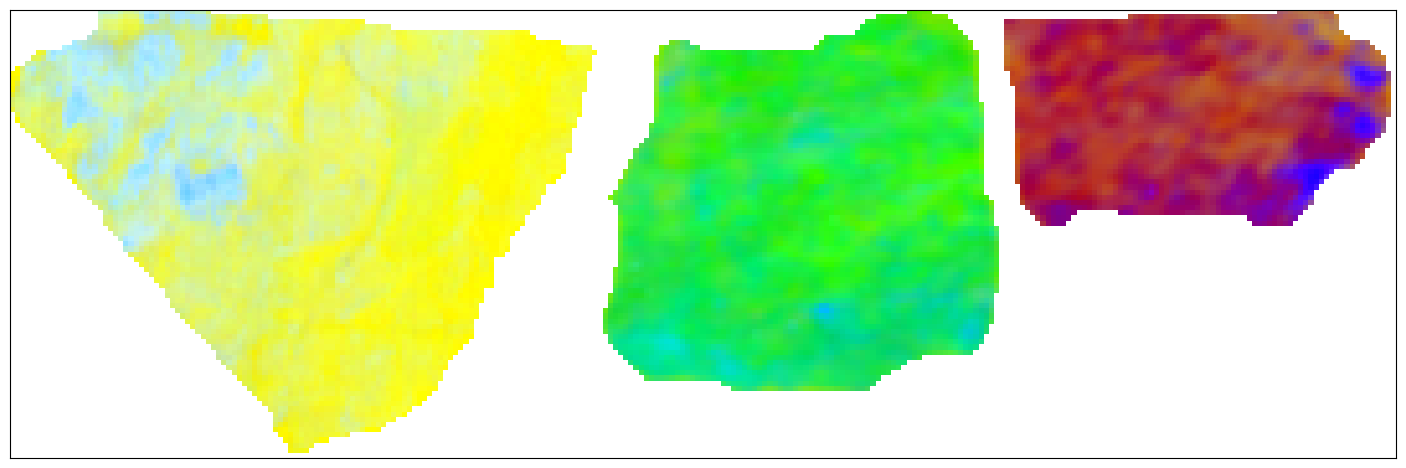

In [10]:
mnf, loadings, means = MNF( image, bands=3 )
mnf.quick_plot((0,1,2), tscale=True, vmin=2, vmax=98 )

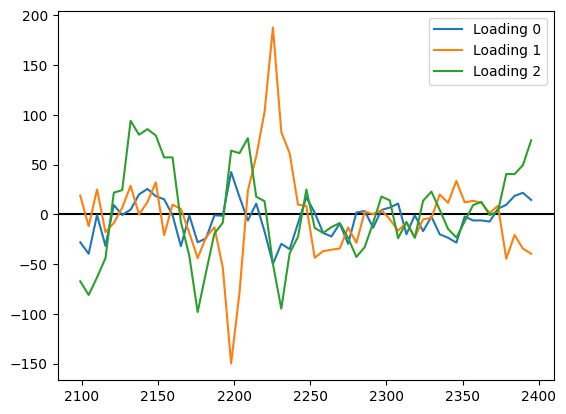

In [11]:
plt.axhline(0,color='k')
for i, b in enumerate(range(pca.band_count())):
    plt.plot(image.get_wavelengths(), loadings[b,:], label="Loading %d"%i)
plt.legend()
plt.show()

Note that while the colours in the above dataset are quite different, the spatial variations highlighted by the MNF match those identified by the PCA. The loading vector returned by MNF also has similarities with the one from PCA.

Now lets compare the MNF and PCA for the hypercloud.

In [12]:
cloud = io.load( 'test_data/hypercloud.ply' )
cloud.decompress()

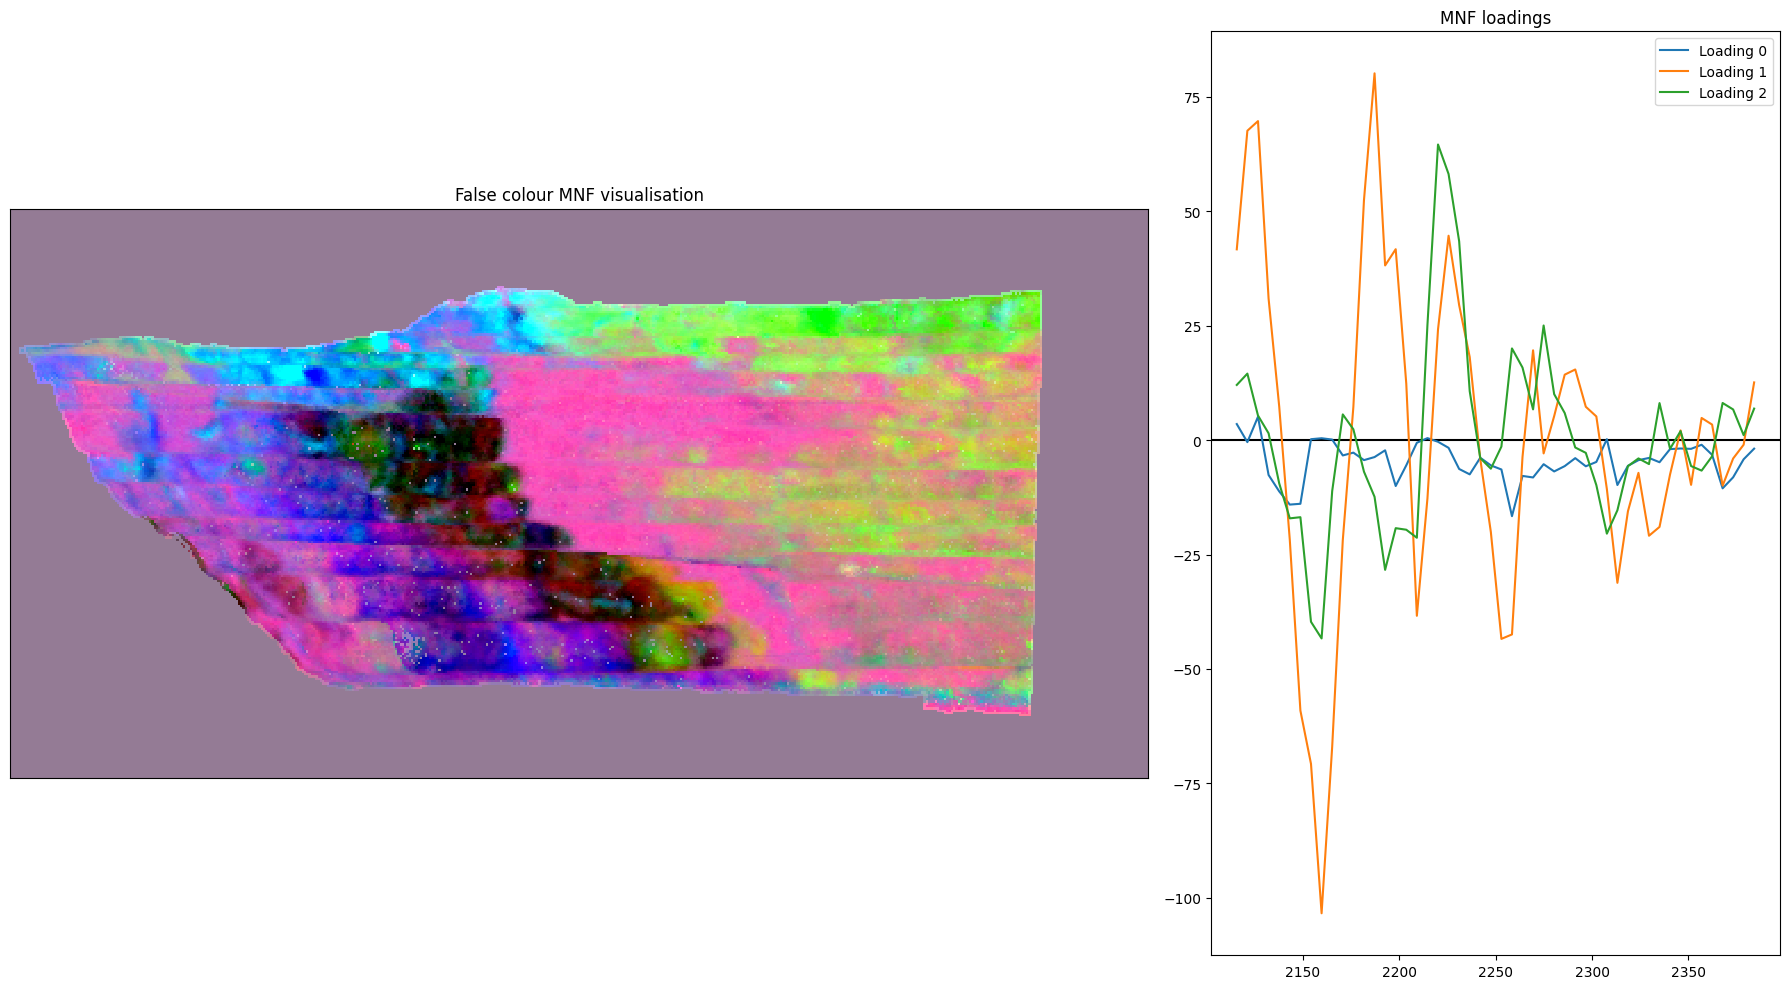

In [13]:
fig,ax = plt.subplots(1,2, figsize=(18,10), gridspec_kw={'width_ratios': [2, 1]})
ax[0].set_title("False colour MNF visualisation")
mnf, loadings, means = MNF( cloud, bands=3 )
mnf.quick_plot((0,1,2), cloud.header.get_camera(0), ax=ax[0],
                        tscale=True, vmin=2, vmax=98, interpolation='none', fill_holes=True)

ax[1].axhline(0,color='k')
for i, b in enumerate(range(mnf.band_count())):
    ax[1].plot(cloud.get_wavelengths(), loadings[b,:], label="Loading %d"%i)
ax[1].legend()
ax[1].set_title("MNF loadings")

fig.tight_layout()
fig.show()

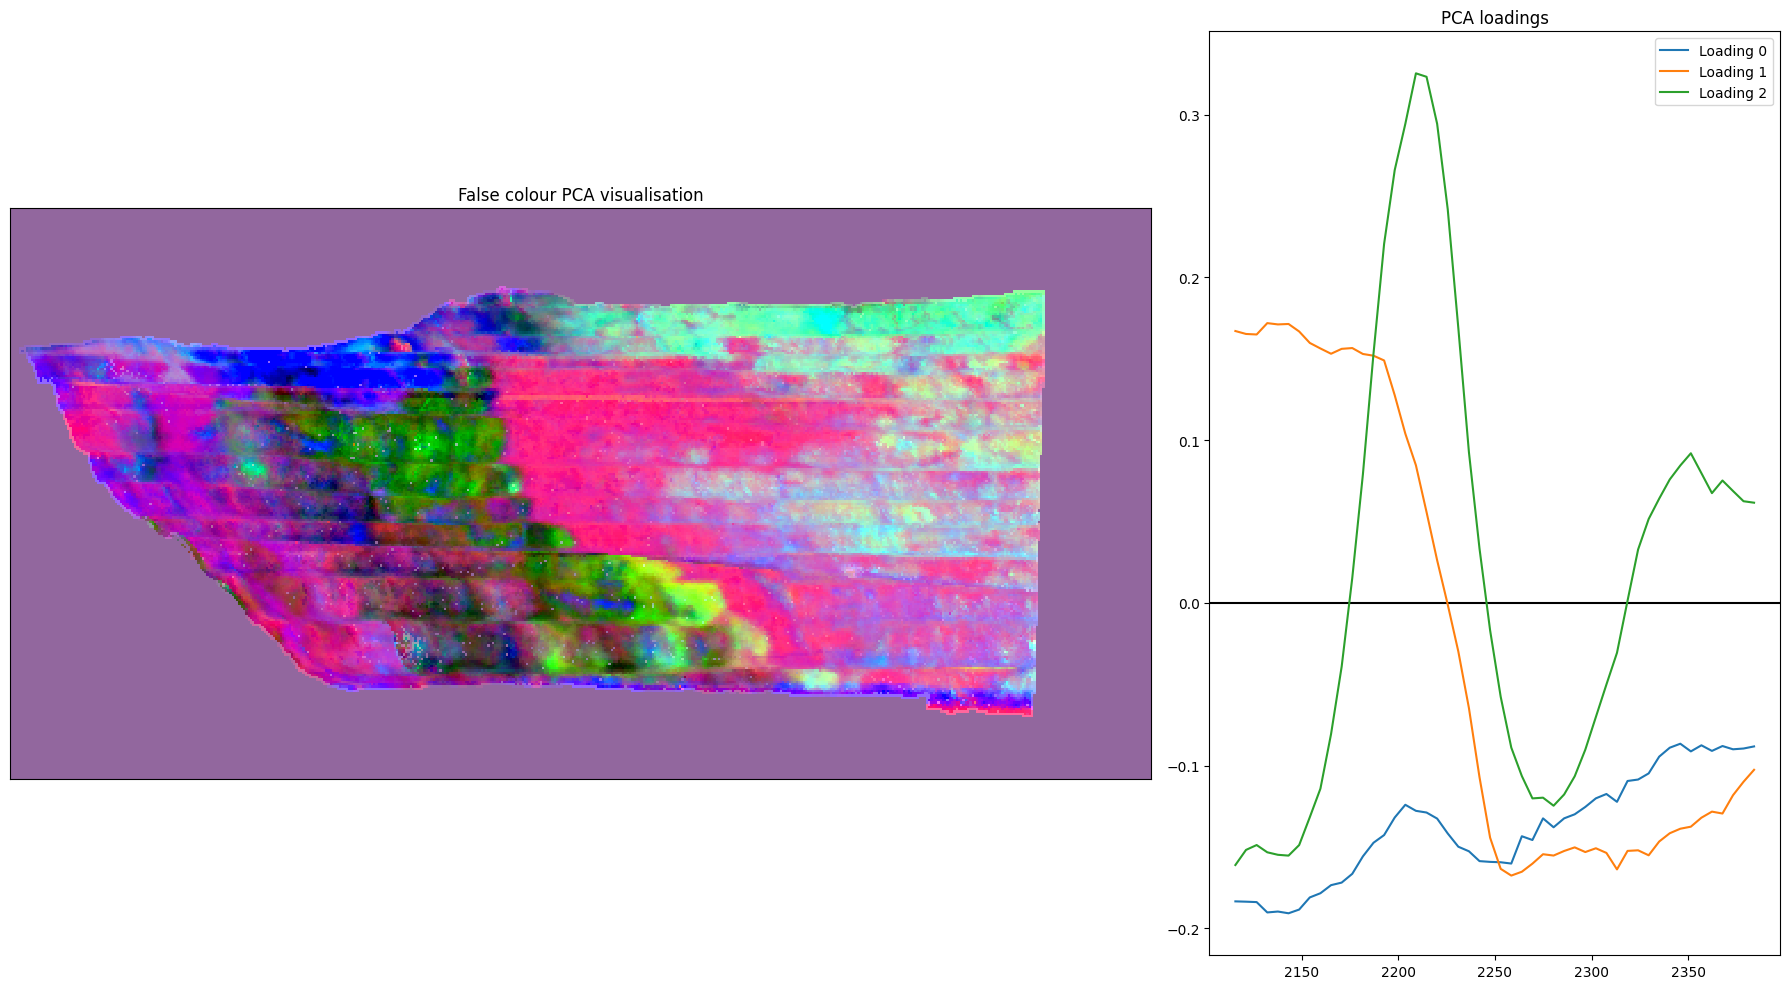

In [14]:
fig,ax = plt.subplots(1,2, figsize=(18,10), gridspec_kw={'width_ratios': [2, 1]})
ax[0].set_title("False colour PCA visualisation")
pca, loadings, means = PCA( cloud, bands=3 )
pca.quick_plot((0,1,2), cloud.header.get_camera(0), ax=ax[0],
                        tscale=True, vmin=2, vmax=98, interpolation='none', fill_holes=True)

ax[1].axhline(0,color='k')
for i, b in enumerate(range(mnf.band_count())):
    ax[1].plot(cloud.get_wavelengths(), loadings[b,:], label="Loading %d"%i)
ax[1].legend()
ax[1].set_title("PCA loadings")

fig.tight_layout()
fig.show()

### 3. Precomputed loading vectors

In some cases it is also useful to compute PCA loading vectors on one dataset and apply them on a different one (with matching number of bands). For example, we can calculate a loading vector using the image samples, and then apply it to the hypercloud to generate a visualisation that maximises discrimination between the samples.

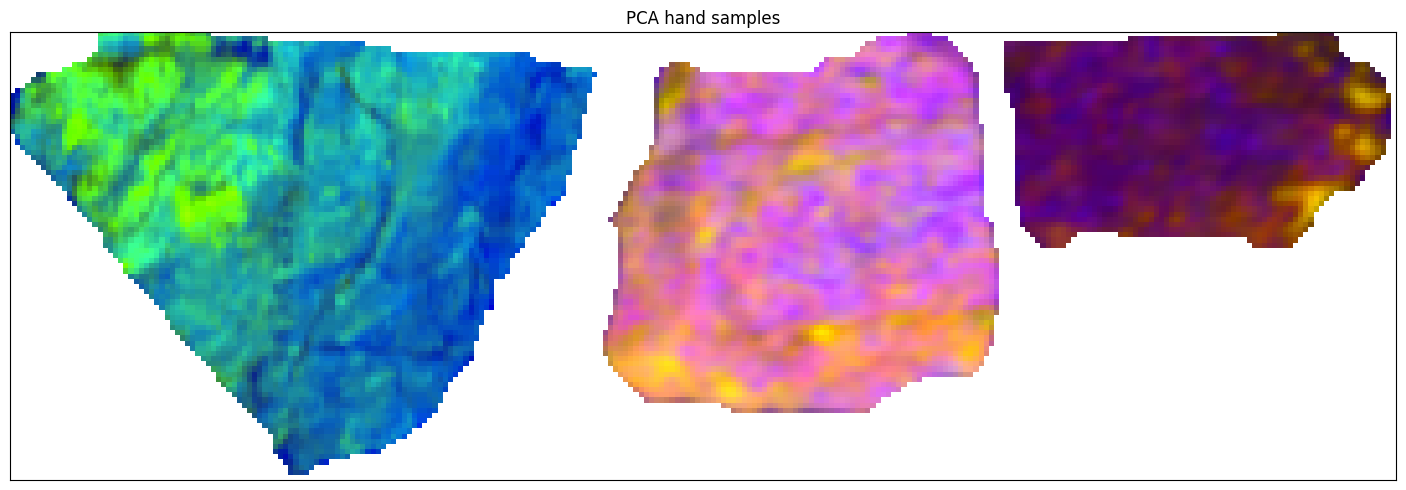

In [15]:
# compute transform
#N.B. we must first resample the datasets so they contain the same bands
pca, loadings, means = PCA(image.resample(cloud.get_wavelengths(),vb=False), bands=3 )

# plot
fig,ax = pca.quick_plot((0,1,2),vmin=2, vmax=98, tscale=True )
ax.set_title("PCA hand samples")
fig.show()

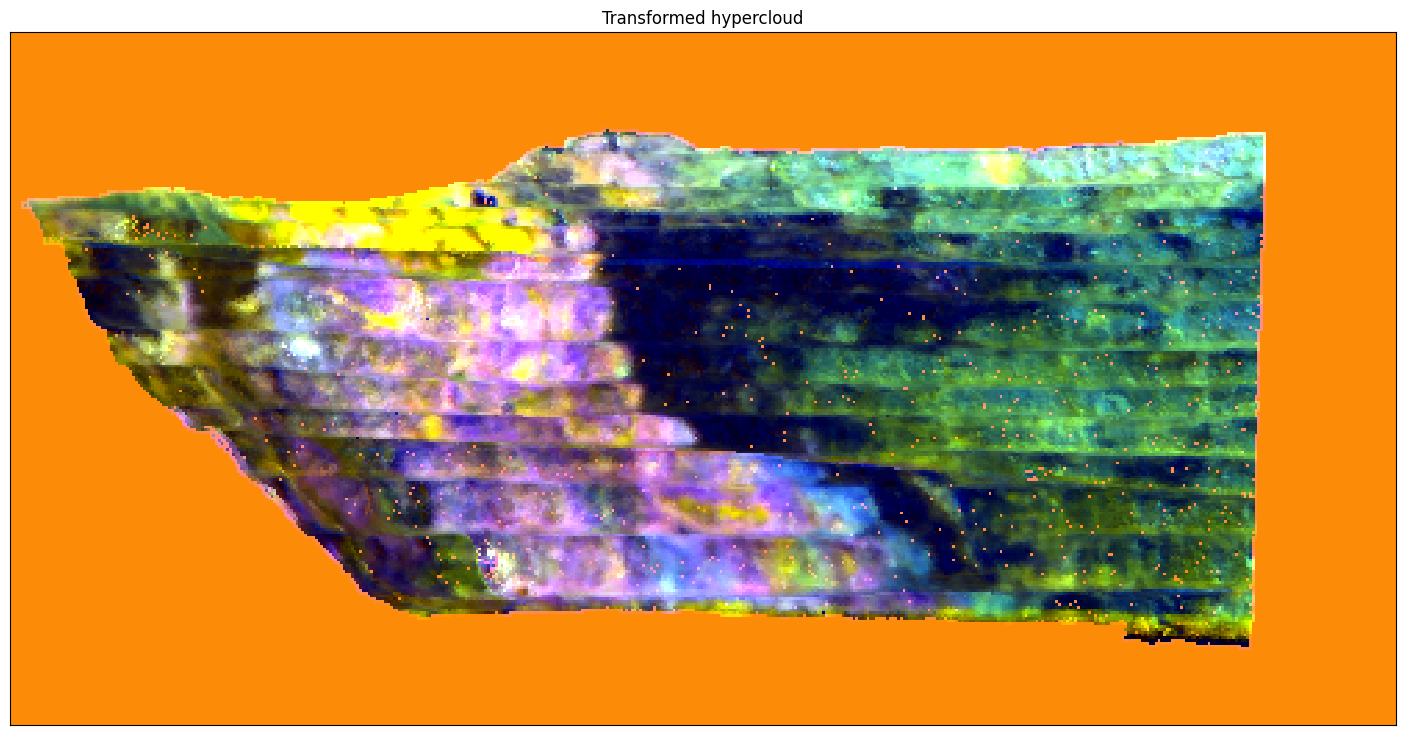

In [16]:
# apply loadings from above to the hypercloud
from hylite.filter import from_loadings
cloud_T = from_loadings( cloud, loadings, means )

# plot
fig,ax = cloud_T.quick_plot((0,1,2),cloud.header.get_camera(0),
                          vmin=2, vmax=98, tscale=True, fill_holes=True)
ax.set_title("Transformed hypercloud")
fig.show()

-----

**Exercise**: *Where in the hypercloud outcrop would you predict that the samples come from? Can you use the PCA data to find the most similar locations to each sample?*

----

